<a href="https://colab.research.google.com/github/bkekgathetse/setswana-offensive-977/blob/main/notebooks/PuoBERTa_TagFreeTest_80_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Fine-Tuning PuoBERTa with 5-Fold CV on 80% Train Set + Final Test on 20% Holdout
# Dataset: 477 Offensive, 500 Non-Offensive Samples

!pip install transformers datasets torch scikit-learn

import os
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, matthews_corrcoef
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, RobertaForSequenceClassification, RobertaTokenizer
from datasets import Dataset
from torch.nn import CrossEntropyLoss

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load training (80%) and testing (20%) CSV files
train_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/training_data.csv')
test_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/testing_data2.csv')
train_df['TEXT'] = train_df['TEXT'].astype(str)
test_df['TEXT'] = test_df['TEXT'].astype(str)

# Load tokenizer and add trigger tokens
tokenizer = RobertaTokenizer.from_pretrained('dsfsi/PuoBERTa')
tokenizer.add_special_tokens({'additional_special_tokens': ['<TRIGGER>', '</TRIGGER>']})

def tokenize_batch(batch):
    return tokenizer(batch['TEXT'], padding='max_length', truncation=True, max_length=128)

# Define evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None, labels=[0, 1])
    return {
        'accuracy': accuracy_score(labels, preds),
        'mcc': matthews_corrcoef(labels, preds),
        'roc_auc': roc_auc_score(labels, torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()),
        'f1_macro': f1.mean(),
        'recall_1': recall[1]
    }

# Define custom loss function for class imbalance
def compute_weighted_loss(model, inputs, return_outputs=False):
    labels = inputs.pop('labels')
    outputs = model(**inputs)
    loss_fct = CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(model.device))
    loss = loss_fct(outputs.logits.view(-1, 2), labels.view(-1))
    return (loss, outputs) if return_outputs else loss

# Training arguments
training_args = TrainingArguments(
    output_dir='/content/drive/My Drive/Colab Notebooks/PuoBERTa-CV-80-20',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy='no',
    eval_strategy='epoch',
    metric_for_best_model='recall_1',
    greater_is_better=True,
    load_best_model_at_end=False
)

# Apply 5-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
best_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_df['TEXT'], train_df['TARGET'])):
    print(f'\n=== Fold {fold + 1}/5 ===')
    train_fold = train_df.iloc[train_idx]
    val_fold = train_df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_fold).map(tokenize_batch, batched=True)
    val_dataset = Dataset.from_pandas(val_fold).map(tokenize_batch, batched=True)
    train_dataset = train_dataset.rename_column('TARGET', 'label')
    val_dataset = val_dataset.rename_column('TARGET', 'label')

    # Convert 'label' column to integers using a mapping
    label_mapping = {'Non-offensive': 0, 'Offensive': 1}
    train_dataset = train_dataset.map(lambda examples: {'label': [label_mapping[x] for x in examples['label']]}, batched=True)
    val_dataset = val_dataset.map(lambda examples: {'label': [label_mapping[x] for x in examples['label']]}, batched=True)

    train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

    model = RobertaForSequenceClassification.from_pretrained('dsfsi/PuoBERTa', num_labels=2)
    model.resize_token_embeddings(len(tokenizer))

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )
    trainer.loss_function = compute_weighted_loss
    trainer.train()
    metrics = trainer.evaluate()
    fold_results.append(metrics)
    best_models.append(model)
    print(metrics)
# Final evaluation on the held-out 20% test set
best_fold_index = np.argmax([r['eval_recall_1'] for r in fold_results])
best_model = best_models[best_fold_index]
print(f'\nBest Fold: Fold {best_fold_index + 1}')

test_dataset = Dataset.from_pandas(test_df).map(tokenize_batch, batched=True)
test_dataset = test_dataset.rename_column('TARGET', 'label') # Changed 'TARGET' to 'TARGET LABEL'

# Convert 'label' column to integers using a mapping before setting the format
label_mapping = {'Non-offensive': 0, 'Offensive': 1}
test_dataset = test_dataset.map(lambda examples: {'label': [label_mapping[x] for x in examples['label']]}, batched=True)

test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

test_trainer = Trainer(
    model=best_model,
    args=TrainingArguments(output_dir='./tmp-test', per_device_eval_batch_size=64),
    compute_metrics=compute_metrics
)
test_metrics = test_trainer.evaluate(test_dataset)
print('\n=== Test Set Metrics ===')
print(test_metrics)

# Save best model and tokenizer to Google Drive
save_dir = '/content/drive/My Drive/Colab Notebooks/PuoBERTa-best-tag-freeTest-model-80-20'
best_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Best performing model saved to: {save_dir}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/196 [00:00<?, ? examples/s]

Map:   0%|          | 0/196 [00:00<?, ? examples/s]


=== Test Set Metrics ===
{'eval_loss': 1.694297194480896, 'eval_model_preparation_time': 0.0035, 'eval_accuracy': 0.6428571428571429, 'eval_mcc': 0.36583928689847384, 'eval_roc_auc': 0.7966457023060797, 'eval_f1_macro': 0.5577047066408769, 'eval_recall_1': 0.2222222222222222, 'eval_runtime': 0.7286, 'eval_samples_per_second': 269.02, 'eval_steps_per_second': 5.49}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best performing model saved to: /content/drive/My Drive/Colab Notebooks/PuoBERTa-best-tag-freeTest-model-80-20


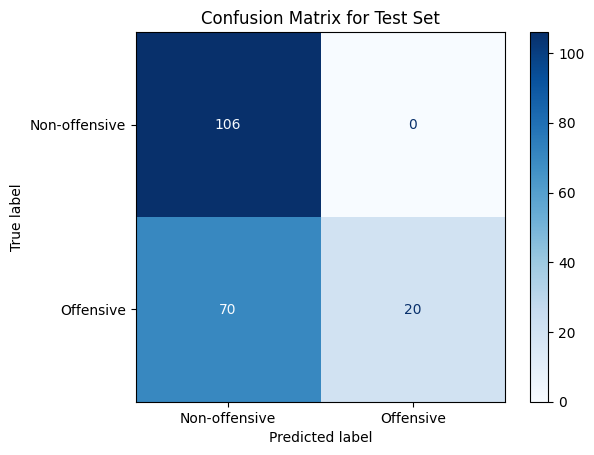

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from the test set
predictions_output = test_trainer.predict(test_dataset)

# Extract true labels and predicted logits
true_labels = predictions_output.label_ids
logits = predictions_output.predictions

# Convert logits to predicted labels (argmax over the logits)
predicted_labels = np.argmax(logits, axis=-1)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

# Define class names for better readability
class_names = ['Non-offensive', 'Offensive']

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Test Set')
plt.show()